# SVM com kernel RBF

**Autor:** Prof. Dr. Sergio Antônio Andrade de Freitas  
**Material da disciplina:** FGA0083 — Aprendizado de Máquina, UnB

## Objetivo e dados

Visualizar uma fronteira não linear em `make_moons`.

**Pergunta-guia:** O que gamma e C alteram na fronteira e nos erros?

Execute as células na ordem e interprete os resultados antes de fazer o exercício.

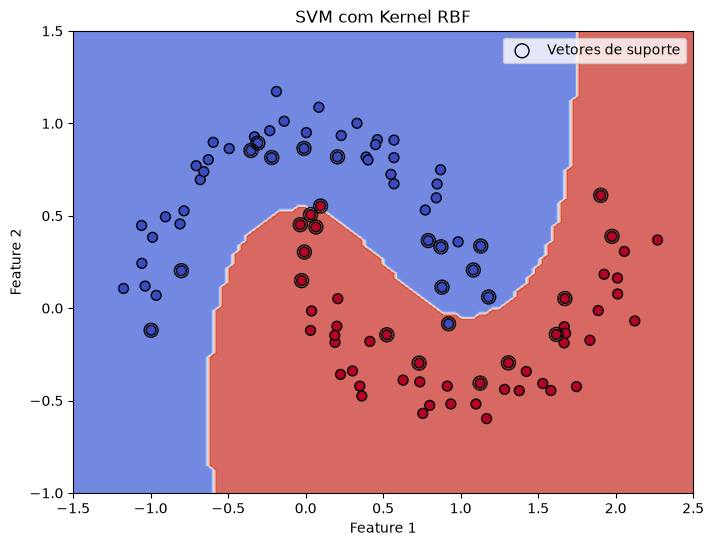

In [1]:
# Exemplo Prático de SVM com Kernel RBF
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC

# Gerar um conjunto de dados não linear
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)

# Treinar o modelo SVM com kernel RBF
model_rbf = SVC(kernel='rbf')
model_rbf.fit(X, y)

# Criar a grade para visualizar a fronteira de decisão
xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 100), np.linspace(-1, 1.5, 100))

# Prever as classificações para cada ponto na grade
Z = model_rbf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotar os dados e a fronteira de decisão
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=50)
plt.scatter(model_rbf.support_vectors_[:, 0], model_rbf.support_vectors_[:, 1], s=100, facecolors='none', edgecolors='black', label='Vetores de suporte')
plt.legend()
plt.title('SVM com Kernel RBF')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## Investigação complementar

Compare a nova medida com a figura ou o resultado anterior. Explique qualquer diferença observada.

In [2]:
from sklearn.model_selection import train_test_split
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
for C, gamma in ((0.1, 0.1), (1, 1), (100, 10)):
    comparacao = SVC(kernel='rbf', C=C, gamma=gamma).fit(X_treino, y_treino)
    print(f'C={C}, gamma={gamma}: treino={comparacao.score(X_treino,y_treino):.2f}; teste={comparacao.score(X_teste,y_teste):.2f}; suportes={len(comparacao.support_vectors_)}')

C=0.1, gamma=0.1: treino=0.79; teste=0.84; suportes=74
C=1, gamma=1: treino=0.97; teste=1.00; suportes=26
C=100, gamma=10: treino=1.00; teste=1.00; suportes=35


## Interpretação e limites

Uma fronteira que segue o treino não garante desempenho em novos dados.

## Exercício

Separe teste, compare valores de C/gamma e explore `data/11.2 - dados_ecommerce_svm.csv`.

Registre a hipótese, a mudança realizada, a métrica ou figura observada e uma conclusão que os dados de fato sustentem.